# ✨ Técnicas de Procesamiento de Lenguaje Natural (PLN) 📖  
## 📝 Cuaderno 06 - *Clasificación de textos (solo sentiment analysis)*  
### *Cuaderno previo -> Clasificación de textos 05*

## 🏆 Clase: Técnicas y herramientas para realizar *sentiment analysis*

📅 **Desarrollado por:** [Julian David Echeverry](mailto:jde@utp.edu.co)

---
## 🔹 Sección 0: Instalación de paquetes y carga de librerías
---

### 🔍 **Objetivo:** En esta sección se instalarán los paquetes y se cargarán las librerías necesarias para ejecutar las celdas posteriores

In [ ]:
!pip install googletrans
!pip install flair
!pip install transformers
!pip install deep_translator
!pip install textblob
!pip install spacytextblob
!pip install spacy

In [ ]:
import googletrans
from googletrans import Translator

In [ ]:
import spacy
# Primero descargamos los modelos
spacy.cli.download("es_core_news_sm")
spacy.cli.download("en_core_web_sm")
# Luego los cargamos
nlp_es = spacy.load("es_core_news_sm")
nlp_en = spacy.load("en_core_web_sm")

✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


---
## 🔹 Sección 1: Introducción al *Sentiment Analysis*
---

#### 🔍 **Objetivo**  
En esta sección exploraremos la teoría detrás del **análisis de sentimientos** (*sentiment analysis*), una tarea clave en **Procesamiento de Lenguaje Natural (PLN)**. Revisaremos los fundamentos, aplicaciones y metodologías más utilizadas para abordar este problema, así como un vistazo a herramientas populares en la actualidad.

---

### 📌 **Introducción**

El **análisis de sentimientos** es una técnica de PLN que permite determinar la **carga emocional** o **polaridad** de un texto. Su objetivo principal es clasificar fragmentos de texto en categorías como:  

- **Positivo** (*happy, great, amazing, love it!*)  
- **Negativo** (*terrible, hate, awful, worst experience!*)  
- **Neutral** (*the product arrived on time, I watched the movie yesterday.*)  

En algunos casos más avanzados, también se pueden detectar emociones más específicas (**ira, alegría, miedo, sorpresa**) o medir la **intensidad** de una emoción dentro de un rango.

El auge de esta tarea se debe al crecimiento exponencial de datos generados en redes sociales, reseñas de productos, atención al cliente y medios digitales, donde la **opinión pública** tiene un gran impacto en las decisiones empresariales y estrategias de mercado.

---

### 🟢 **¿Por qué es importante el *Sentiment Analysis*?**

El **análisis de sentimientos** se ha convertido en una herramienta clave para la toma de decisiones en diversos campos, incluyendo:  

✅ **Empresas y marketing:** evaluar la percepción de los clientes sobre productos y servicios.  
✅ **Atención al cliente:** detectar automáticamente quejas y comentarios negativos.  
✅ **Política y encuestas:** medir el sentimiento público respecto a campañas o candidatos.  
✅ **Redes sociales y medios:** analizar tendencias y reacciones ante eventos globales.  
✅ **Salud mental:** monitorear el estado emocional de usuarios en plataformas de apoyo.  

Gracias a los avances en **aprendizaje automático** y **deep learning**, los modelos actuales pueden analizar grandes volúmenes de texto con alta precisión, proporcionando *insights* en tiempo real.

---

### 🔍 **Metodologías para *Sentiment Analysis***

Existen diferentes enfoques para realizar análisis de sentimientos, que varían en complejidad y precisión:

1️⃣ **Basados en diccionarios y reglas** (*Lexicon-based methods*):  
   - Se utilizan listas predefinidas de palabras con valores de polaridad asignados (*positivo, negativo*).  
   - Ejemplo: *VADER* (NLTK), *SentiWordNet*.  
   - Rápidos, pero limitados cuando hay sarcasmo o contexto complejo.

2️⃣ **Basados en aprendizaje automático** (*Machine Learning-based methods*):  
   - Se entrenan modelos con datos etiquetados (*positivo, negativo, neutral*).  
   - Algoritmos como **Naive Bayes**, **SVM**, **Random Forest**.  
   - Requieren ingeniería de características (*TF-IDF, Bag of Words*).

3️⃣ **Basados en redes neuronales y *Deep Learning***:  
   - Modelos de última generación como **LSTMs, CNNs** y **Transformers** (*BERT, RoBERTa, GPT*).  
   - Capturan mejor el **contexto** y la **semántica** del lenguaje.  
   - Son más precisos, pero requieren grandes cantidades de datos y recursos computacionales.

---

### 🛠️ **Herramientas Populares en *Sentiment Analysis***

A continuación, algunas de las herramientas más utilizadas para realizar análisis de sentimientos en Python:

| 🚀 **Herramienta**       | ⚙️ **Enfoque**                      | 📌 **Descripción** |
|-------------------------|--------------------------------|-----------------|
| **TextBlob**            | Diccionarios / Lexicón         | Fácil de usar, basado en reglas de polaridad.  |
| **VADER (NLTK)**        | Diccionarios / Lexicón        | Optimizado para redes sociales, detecta énfasis y sarcasmo.  |
| **spaCy + TextBlob**    | Híbrido                       | Combinación de NLP con *sentiment analysis*.  |
| **scikit-learn (SVM, Naive Bayes)** | Machine Learning  | Modelos clásicos entrenados con características manuales. |
| **Hugging Face Transformers (BERT, RoBERTa)** | Deep Learning | Modelos avanzados pre-entrenados para alto rendimiento. |

Dependiendo del caso de uso, se elige un método **rápido y simple** (*lexicon-based*) o uno **más preciso y complejo** (*deep learning*).

---

### 🔎 **Desafíos del *Sentiment Analysis***

A pesar de sus avances, el análisis de sentimientos enfrenta varios desafíos, tales como:

❌ **Sarcasmo y ironía:** "¡Qué excelente servicio… me dejaron esperando 3 horas!"  
❌ **Contexto y ambigüedad:** "El final de la película fue muy frío." (¿emocional o literal?)  
❌ **Negaciones y dobles sentidos:** "No es una mala opción." (en realidad es positivo).  
❌ **Multimodalidad:** A veces, los emojis y el tono cambian completamente el significado.  

Los modelos de PLN siguen evolucionando para abordar estas dificultades con técnicas como **embeddings contextuales** y **atención neuronal**.

---

### 🎯 **Conclusión**
El **análisis de sentimientos** es una de las tareas más utilizadas en PLN y sigue en constante evolución. Su aplicación abarca desde el análisis de opiniones en redes sociales hasta la evaluación de la reputación de marcas. Con el auge de los modelos basados en **inteligencia artificial**, esta tarea se ha vuelto más **precisa**, **automatizada** y útil para diversos sectores.

En las siguientes secciones exploraremos cómo implementar *sentiment analysis* en Python utilizando algunas de las herramientas mencionadas. 🚀

---

**📌 Nota:** En la práctica, la elección del método dependerá de la precisión requerida, los recursos computacionales y la cantidad de datos disponibles.

---

## 🔹 Sección 2: Empleando VADER con NLTK

---

### 📌 ¿Qué es VADER?
**VADER** (*Valence Aware Dictionary and sEntiment Reasoner*) es un lexicón optimizado para el análisis de sentimientos en **textos cortos e informales**, como publicaciones en redes sociales, comentarios en línea y mensajes de chat. Forma parte de la librería **NLTK (Natural Language Toolkit)** en Python.

A diferencia de otros enfoques basados en diccionarios, VADER está diseñado para manejar:
- **Negaciones** (*not good* → negativo)
- **Puntuación** (*amazing!!!* → más positivo)
- **Mayúsculas** (*I LOVE this* → más positivo que *I love this*)
- **Emojis y emoticonos** (*:-)*, *😃* → positivo)
- **Slang y abreviaciones** (*LOL, OMG* → positivo)

---

### 🛠️ ¿Cómo usar VADER en Python?
Para usar VADER con **NLTK**, primero es necesario instalar y descargar los recursos de NLTK:

```python
# Instalación de NLTK (si no está instalado)
# !pip install nltk

import nltk
nltk.download('vader_lexicon')

from nltk.sentiment import SentimentIntensityAnalyzer

# Creamos un analizador de sentimientos con VADER
sia = SentimentIntensityAnalyzer()

# Ejemplo de texto
text = "I absolutely love this product! It's amazing 😍"

# Obtenemos el análisis de sentimiento
sentiment_scores = sia.polarity_scores(text)
print(sentiment_scores)
````

El resultado es un diccionario con cuatro valores clave:

- `neg:` Proporción de palabras negativas en el texto.
- `neu:` Proporción de palabras neutras.
- `pos:` Proporción de palabras positivas.
- `compound:` Puntuación general del texto (rango de -1 a 1), donde:

  - Positivo: > 0.05
  - Neutral: Entre -0.05 y 0.05
  - Negativo: < -0.05

---

### 🚀 Ventajas de usar VADER

✅ Optimizado para redes sociales y lenguaje informal.

✅ No necesita entrenamiento previo, ya que usa un lexicón predefinido.

✅ Maneja sarcasmo y énfasis mejor que otros métodos lexicón-based.

✅ Rápido y eficiente, ideal para grandes volúmenes de datos.

Sin embargo, no es perfecto y puede tener dificultades con contextos más complejos o ironía extrema.

---

### 🎯 Conclusión

VADER es una herramienta poderosa y sencilla para análisis de sentimientos en inglés, especialmente útil para datos provenientes de redes sociales. Aunque es rápido y preciso en muchas situaciones, para textos más complejos o en otros idiomas puede ser necesario recurrir a modelos más avanzados, como BERT o RoBERTa.

In [ ]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from deep_translator import GoogleTranslator

# Download the VADER lexicon (necessary for sentiment analysis)
nltk.download('vader_lexicon')

# Initialize the SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# ---------------------------------------
# Example 1: Simple Sentiment Analysis in English
# ---------------------------------------
print("\n🔹 Example 1: Basic Sentiment Analysis in English")
text_english = "I love using NLTK for sentiment analysis!"
sentiment_english = sia.polarity_scores(text_english)
print(f"Text: {text_english}")
print(f"Sentiment: {sentiment_english}")

# ---------------------------------------
# Example 2: Handling Different Sentiment Strengths
# ---------------------------------------
print("\n🔹 Example 2: Varying Sentiment Intensity")

texts = [
    "I absolutely love this product! It's amazing 😍",  # Strongly Positive
    "The movie was okay, not great but not terrible.",  # Neutral
    "I really hate waiting in long lines. It's so frustrating!",  # Negative
    "Ugh... this is the worst experience ever! 😡"  # Strongly Negative
]

for text in texts:
    print(f"\nText: {text}")
    print("Sentiment:", sia.polarity_scores(text))

# ---------------------------------------
# Example 3: Detecting Sarcasm and Emojis
# ---------------------------------------
print("\n🔹 Example 3: Handling Sarcasm and Emojis")

sarcasm_texts = [
    "Oh great, another Monday... just what I needed 😒",  # Sarcastic
    "Wow, this restaurant is amazing! The food is cold and the service is slow. 👍",  # Mixed Sentiment
]

for text in sarcasm_texts:
    print(f"\nText: {text}")
    print("Sentiment:", sia.polarity_scores(text))

# ---------------------------------------
# Example 4: Sentiment Analysis in Spanish (Translated to English)
# ---------------------------------------
print("\n🔹 Example 4: Sentiment Analysis in Spanish (via Translation)")

spanish_texts = [
    "Me encanta este producto, es fantástico.",  # Positive
    "La película fue terrible, no la recomendaría.",  # Negative
    "El clima hoy está normal, ni muy bueno ni muy malo."  # Neutral
]

for text in spanish_texts:
    translated_text = GoogleTranslator(source='es', target='en').translate(text)
    sentiment_scores = sia.polarity_scores(translated_text)

    print(f"\nOriginal (Spanish): {text}")
    print(f"Translated (English): {translated_text}")
    print("Sentiment:", sentiment_scores)

# ---------------------------------------
# Example 5: Processing a List of Sentences at Once
# ---------------------------------------
print("\n🔹 Example 5: Batch Sentiment Analysis")

batch_texts = [
    "I had a fantastic time at the concert! 🎶",
    "I'm so tired of this terrible weather.",
    "The customer service was excellent, I highly recommend this company.",
    "I regret buying this product, it broke after one use.",
]

# Process all sentences in one go
sentiment_results = {text: sia.polarity_scores(text) for text in batch_texts}

for text, scores in sentiment_results.items():
    print(f"\nText: {text}")
    print(f"Sentiment: {scores}")


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...



🔹 Example 1: Basic Sentiment Analysis in English
Text: I love using NLTK for sentiment analysis!
Sentiment: {'neg': 0.0, 'neu': 0.527, 'pos': 0.473, 'compound': 0.6696}

🔹 Example 2: Varying Sentiment Intensity

Text: I absolutely love this product! It's amazing 😍
Sentiment: {'neg': 0.0, 'neu': 0.318, 'pos': 0.682, 'compound': 0.862}

Text: The movie was okay, not great but not terrible.
Sentiment: {'neg': 0.166, 'neu': 0.464, 'pos': 0.37, 'compound': 0.3887}

Text: I really hate waiting in long lines. It's so frustrating!
Sentiment: {'neg': 0.534, 'neu': 0.466, 'pos': 0.0, 'compound': -0.8412}

Text: Ugh... this is the worst experience ever! 😡
Sentiment: {'neg': 0.423, 'neu': 0.577, 'pos': 0.0, 'compound': -0.6588}

🔹 Example 3: Handling Sarcasm and Emojis

Text: Oh great, another Monday... just what I needed 😒
Sentiment: {'neg': 0.0, 'neu': 0.594, 'pos': 0.406, 'compound': 0.6249}

Text: Wow, this restaurant is amazing! The food is cold and the service is slow. 👍
Sentiment: {'neg': 

---
## 🔹 Sección 3: Empleando TextBlob para *Sentiment Analysis*
---

### 📌 ¿Qué es TextBlob?

**TextBlob** es una biblioteca de **Procesamiento de Lenguaje Natural (PLN) en Python** diseñada para facilitar tareas comunes como:
- Tokenización y lematización.
- Traducción y corrección gramatical.
- Extracción de frases nominales y etiquetas gramaticales.
- **Análisis de sentimientos** (*Sentiment Analysis*).

Para el análisis de sentimientos, **TextBlob** utiliza un enfoque basado en **diccionarios léxicos predefinidos**, en particular el **lexicón de patrones**, que asigna valores de polaridad y subjetividad a las palabras.

---

### 🛠️ **Cómo usar TextBlob para *Sentiment Analysis* en Python**
Para instalarlo, se puede ejecutar:
```bash
!pip install textblob
````

y luego ejecutarlo con algo como

```python
from textblob import TextBlob

# Texto de ejemplo
text = "I love using TextBlob for sentiment analysis! It's fantastic."

# Crear un objeto TextBlob
blob = TextBlob(text)

# Obtener análisis de sentimiento
polarity = blob.sentiment.polarity  # Entre -1.0 (negativo) y 1.0 (positivo)
subjectivity = blob.sentiment.subjectivity  # Entre 0.0 (objetivo) y 1.0 (subjetivo)

print(f"Text: {text}")
print(f"Polarity: {polarity}")
print(f"Subjectivity: {subjectivity}")
````

Interpretación de resultados:

- Polaridad (polarity):
  - 1.0 → Muy positivo 😃
  - 0.0 → Neutro 😐
  - -1.0 → Muy negativo 😠
- Subjetividad (subjectivity):
  - 1.0 → Muy subjetivo (opinión, emociones).
  - 0.0 → Muy objetivo (hechos, datos).

---

### 🚀 Ventajas de usar TextBlob

✅ Fácil de usar: API intuitiva que permite realizar análisis de sentimiento en pocas líneas de código.
✅ Ligero y eficiente: Ideal para proyectos pequeños y prototipos.
✅ Incluye otras funciones NLP: Además del análisis de sentimientos, puede realizar traducción, tokenización y etiquetado gramatical.
✅ Pre-entrenado: No necesita entrenar modelos, usa un lexicón léxico basado en Pattern.

---

### 🔎 Limitaciones de TextBlob

❌ Optimizado solo para inglés: Aunque se puede combinar con un traductor, no es ideal para español u otros idiomas.
❌ No maneja bien contexto y sarcasmo: No utiliza modelos de aprendizaje profundo como Transformers (BERT, RoBERTa).
❌ Basado en reglas estáticas: No aprende de nuevos datos como los modelos de Machine Learning.

---

### 🎯 Conclusión
TextBlob es una excelente herramienta para análisis de sentimientos en inglés cuando se necesita una solución rápida y sencilla. Sin embargo, para tareas más avanzadas que requieran mayor precisión o el manejo de contexto y sarcasmo, se recomienda utilizar modelos basados en Deep Learning, como BERT o RoBERTa.


In [ ]:
from textblob.exceptions import NotTranslated

# --------------------------------------------
# Example 1: Basic Sentiment Analysis in English
# --------------------------------------------
print("\n🔹 Example 1: Basic Sentiment Analysis in English")

text_english = "TextBlob is very easy to use for sentiment analysis."
blob = TextBlob(text_english)

print(f"Text: {text_english}")
print(f"Polarity: {blob.sentiment.polarity}")
print(f"Subjectivity: {blob.sentiment.subjectivity}")

# --------------------------------------------
# Example 2: Handling Stronger Sentiment & Sarcasm
# --------------------------------------------
print("\n🔹 Example 2: Varying Sentiment Strengths & Sarcasm")

texts = [
    "I absolutely love this product! It's fantastic and works perfectly!",  # Strongly Positive
    "The movie was just okay, nothing special.",  # Neutral
    "I hate waiting in long lines. It's the worst experience ever!",  # Strongly Negative
    "Oh great, another Monday... just what I needed. 😒",  # Sarcasm (Hard for TextBlob)
]

for text in texts:
    blob = TextBlob(text)
    print(f"\nText: {text}")
    print(f"Polarity: {blob.sentiment.polarity}")
    print(f"Subjectivity: {blob.sentiment.subjectivity}")

# --------------------------------------------
# Example 3: Sentiment Analysis in Other Languages
# --------------------------------------------
print("\n🔹 Example 3: Sentiment Analysis in Other Languages (via Translation)")

texts_multilingual = {
    "es": "Este producto es increíble, me encanta.",  # Spanish
    "fr": "Je déteste attendre dans les files d'attente.",  # French
    "de": "Der Film war schrecklich, ich empfehle ihn nicht.",  # German
    "it": "Il cibo era delizioso, ci tornerò sicuramente.",  # Italian
}

for lang, text in texts_multilingual.items():
    try:
        translated_text = GoogleTranslator(source=lang, target="en").translate(text)  # Translate to English
        sentiment = TextBlob(translated_text).sentiment
    except Exception as e:  # Handle errors
        translated_text = "Translation failed"
        sentiment = TextBlob(text).sentiment  # Use original text as fallback

    print(f"\nOriginal ({lang.upper()}): {text}")
    print(f"Translated (EN): {translated_text}")
    print(f"Polarity: {sentiment.polarity}")
    print(f"Subjectivity: {sentiment.subjectivity}")

# --------------------------------------------
# Example 4: Batch Processing Multiple Sentences
# --------------------------------------------
print("\n🔹 Example 4: Batch Sentiment Analysis")

batch_texts = [
    "This book is a masterpiece! Highly recommended. 📚",
    "The service at this restaurant was awful, I would never come back.",
    "I feel indifferent about this new software update.",
    "What a terrible day! Everything went wrong.",
    "I'm so excited for my vacation next week! 🌴"
]

sentiment_results = {text: TextBlob(text).sentiment for text in batch_texts}

for text, scores in sentiment_results.items():
    print(f"\nText: {text}")
    print(f"Polarity: {scores.polarity}")
    print(f"Subjectivity: {scores.subjectivity}")


🔹 Example 1: Basic Sentiment Analysis in English
Text: TextBlob is very easy to use for sentiment analysis.
Polarity: 0.5633333333333334
Subjectivity: 1.0

🔹 Example 2: Varying Sentiment Strengths & Sarcasm

Text: I absolutely love this product! It's fantastic and works perfectly!
Polarity: 0.6749999999999999
Subjectivity: 0.8333333333333334

Text: The movie was just okay, nothing special.
Polarity: 0.4285714285714286
Subjectivity: 0.5357142857142857

Text: I hate waiting in long lines. It's the worst experience ever!
Polarity: -0.6166666666666667
Subjectivity: 0.7666666666666666

Text: Oh great, another Monday... just what I needed. 😒
Polarity: 0.8
Subjectivity: 0.75

🔹 Example 3: Sentiment Analysis in Other Languages (via Translation)

Original (ES): Este producto es increíble, me encanta.
Translated (EN): This product is incredible, I love it.
Polarity: 0.7
Subjectivity: 0.75

Original (FR): Je déteste attendre dans les files d'attente.
Translated (EN): I hate to wait in the queues

---
## 🔹 Sección 4: Empleando spaCyTextBlob para *Sentiment Analysis*
---

### 📌 ¿Qué es spaCyTextBlob?

**spaCyTextBlob** es una extensión de **spaCy** que permite integrar el análisis de sentimientos de **TextBlob** dentro del flujo de procesamiento de **spaCy**. Combina la facilidad de uso de **TextBlob** con la eficiencia y flexibilidad de **spaCy**, permitiendo analizar el sentimiento de un texto de manera sencilla mientras se aprovechan otras capacidades de NLP, como la tokenización, etiquetado gramatical y reconocimiento de entidades.

**Características principales:**
- Evalúa la **polaridad** (positivo o negativo) y **subjetividad** (opinión o hecho) de un texto.
- Se integra directamente como una **tubería (*pipeline*)** en spaCy.
- Se basa en un **lexicón predefinido** y es ideal para textos en inglés.

---

### 🛠️ **Cómo usar spaCyTextBlob en Python**
Para instalarlo, se debe ejecutar:

```bash
!pip install spacy spacytextblob
```

Luego, se descarga el modelo de lenguaje de spaCy (por ejemplo, en inglés):

```python
import spacy
spacy.cli.download("en_core_web_sm")
# Y se cargan los modelos
nlp_en = spacy.load("en_core_web_sm")
```

---

### 🚀 Ventajas de usar spaCyTextBlob

✅ Fácil integración con spaCy: Se puede utilizar dentro de un pipeline sin necesidad de procesamiento adicional.
✅ Eficiente y rápido: Permite analizar sentimiento mientras se extraen otras características del texto (POS tagging, NER, etc.).
✅ Ideal para textos cortos y redes sociales: Basado en lexicones predefinidos que funcionan bien en inglés.
✅ No requiere entrenamiento: Utiliza un modelo de sentimientos basado en diccionarios, por lo que funciona de inmediato.

---

### 🔎 Limitaciones de spaCyTextBlob

❌ Optimizado solo para inglés: Aunque se puede usar con textos en otros idiomas, no es tan preciso.
❌ No maneja bien contexto o sarcasmo: No utiliza técnicas avanzadas de Deep Learning como BERT o Transformers.
❌ Basado en reglas estáticas: Su precisión depende de su lexicón, lo que puede ser una limitación en textos complejos.

---

### 🎯 Conclusión
spaCyTextBlob es una excelente herramienta para realizar análisis de sentimientos de forma rápida y sencilla dentro del ecosistema de spaCy. Su facilidad de integración y velocidad lo hacen ideal para tareas simples de procesamiento de texto, aunque para casos más avanzados se recomienda el uso de modelos más sofisticados como BERT o RoBERTa.

In [ ]:
import spacy
from spacytextblob.spacytextblob import SpacyTextBlob
from deep_translator import GoogleTranslator

# --------------------------------------------
# Load English NLP model and add spaCyTextBlob
# --------------------------------------------
nlp_en = spacy.load("en_core_web_sm")
nlp_en.add_pipe("spacytextblob")

# --------------------------------------------
# Example 1: Basic Sentiment Analysis in English
# --------------------------------------------
print("\n🔹 Example 1: Basic Sentiment Analysis in English")

text_english = "I don't like the fact that the sky is so blue, especially during summer days."
doc = nlp_en(text_english)

print(f"Text: {text_english}")
print(f"Polarity: {doc._.blob.polarity}")  # Polarity: -1 (negative) to 1 (positive)
print(f"Subjectivity: {doc._.blob.subjectivity}")  # 0 (objective) to 1 (subjective)
print(f"Assessments: {doc._.blob.sentiment_assessments}")  # Breakdown of sentiment scores

# --------------------------------------------
# Example 2: Handling Different Sentiment Intensities
# --------------------------------------------
print("\n🔹 Example 2: Varying Sentiment Strengths")

texts = [
    "I absolutely love this product! It's fantastic and works perfectly!",  # Strongly Positive
    "The movie was okay, not great but not terrible.",  # Neutral
    "I hate waiting in long lines. It's the worst experience ever!",  # Strongly Negative
    "Oh great, another Monday... just what I needed. 😒",  # Sarcasm (Hard for TextBlob)
]

for text in texts:
    doc = nlp_en(text)
    print(f"\nText: {text}")
    print(f"Polarity: {doc._.blob.polarity}")
    print(f"Subjectivity: {doc._.blob.subjectivity}")

# --------------------------------------------
# Example 3: Sentiment Analysis in Other Languages (via Deep Translator)
# --------------------------------------------
print("\n🔹 Example 3: Sentiment Analysis in Other Languages (via Translation)")

texts_multilingual = {
    "es": "Este producto es increíble, me encanta.",  # Spanish
    "fr": "Je déteste attendre dans les files d'attente.",  # French
    "de": "Der Film war schrecklich, ich empfehle ihn nicht.",  # German
    "it": "Il cibo era delizioso, ci tornerò sicuramente.",  # Italian
}

for lang, text in texts_multilingual.items():
    try:
        translated_text = GoogleTranslator(source=lang, target="en").translate(text)  # Translate to English
        doc_translated = nlp_en(translated_text)  # Process translated text
    except Exception as e:  # Handle translation errors
        translated_text = "Translation failed"
        doc_translated = nlp_en(text)  # Use original text as fallback

    print(f"\nOriginal ({lang.upper()}): {text}")
    print(f"Translated (EN): {translated_text}")
    print(f"Polarity: {doc_translated._.blob.polarity}")
    print(f"Subjectivity: {doc_translated._.blob.subjectivity}")

# --------------------------------------------
# Example 4: Batch Processing Multiple Sentences
# --------------------------------------------
print("\n🔹 Example 4: Batch Sentiment Analysis")

batch_texts = [
    "This book is a masterpiece! Highly recommended. 📚",
    "The service at this restaurant was awful, I would never come back.",
    "I feel indifferent about this new software update.",
    "What a terrible day! Everything went wrong.",
    "I'm so excited for my vacation next week! 🌴"
]

sentiment_results = {text: nlp_en(text)._.blob.sentiment for text in batch_texts}

for text, sentiment in sentiment_results.items():
    print(f"\nText: {text}")
    print(f"Polarity: {sentiment[0]}")  # polarity
    print(f"Subjectivity: {sentiment[1]}")  # subjectivity



🔹 Example 1: Basic Sentiment Analysis in English
Text: I don't like the fact that the sky is so blue, especially during summer days.
Polarity: 0.0
Subjectivity: 0.55
Assessments: Sentiment(polarity=0.0, subjectivity=0.55, assessments=[(['blue'], 0.0, 0.1, None), (['especially'], 0.0, 1.0, None)])

🔹 Example 2: Varying Sentiment Strengths

Text: I absolutely love this product! It's fantastic and works perfectly!
Polarity: 0.6749999999999999
Subjectivity: 0.8333333333333334

Text: The movie was okay, not great but not terrible.
Polarity: 0.19999999999999998
Subjectivity: 0.75

Text: I hate waiting in long lines. It's the worst experience ever!
Polarity: -0.6166666666666667
Subjectivity: 0.7666666666666666

Text: Oh great, another Monday... just what I needed. 😒
Polarity: 0.8
Subjectivity: 0.75

🔹 Example 3: Sentiment Analysis in Other Languages (via Translation)

Original (ES): Este producto es increíble, me encanta.
Translated (EN): This product is incredible, I love it.
Polarity: 0.7


---
## 🔹 **Sección 5: Empleando *Transformers* para *Sentiment Analysis***
---

### 📌 ¿Qué son los modelos *Transformers*?

Los **Transformers** son una arquitectura de redes neuronales profundas introducida por **Vaswani et al. (2017)** en el paper "*Attention is All You Need*". Esta arquitectura ha revolucionado el campo del **Procesamiento de Lenguaje Natural (PLN)**, reemplazando enfoques tradicionales como **RNNs y LSTMs** con un mecanismo basado en **autoatención (self-attention)**.

Los modelos *Transformers* más populares incluyen:
- **BERT (Bidirectional Encoder Representations from Transformers)**
- **GPT (Generative Pre-trained Transformer)**
- **RoBERTa (Robustly Optimized BERT Approach)**
- **DistilBERT (versión ligera de BERT, optimizada para eficiencia)**

---

### 🔍 **¿Cómo se usan los *Transformers* para *Sentiment Analysis*?**

Los modelos *Transformers* pueden ser utilizados para análisis de sentimientos a través de dos enfoques principales:
1. **Modelos preentrenados y ajustados (*fine-tuning*)**  
   - Se entrenan con grandes volúmenes de datos y se ajustan con ejemplos específicos de sentimiento.
   - Ejemplo: Un BERT entrenado con reseñas de productos para clasificar emociones.

2. **Uso directo mediante *pipelines* en Hugging Face**  
   - Se pueden usar modelos preentrenados sin necesidad de entrenamiento adicional.
   - Hugging Face facilita esta implementación con su API `pipeline()`.

#### 📌 **Ejemplo de uso en Python (Hugging Face)**
```python
# Instalar transformers si es necesario
# !pip install transformers

from transformers import pipeline

# Cargar un pipeline preentrenado para análisis de sentimiento
sentiment_pipeline = pipeline("sentiment-analysis")

# Texto de ejemplo
text = "I absolutely love this product! It's fantastic."

# Obtener sentimiento
result = sentiment_pipeline(text)

# Mostrar resultado
print(result)
```
✅ Salida esperada:
```python
[{'label': 'POSITIVE', 'score': 0.9998}]
 ```
 Indica que el modelo clasifica el texto como positivo con alta confianza.

 ---

 ### 🚀 Ventajas del uso de Transformers en Sentiment Analysis

✅ Alto rendimiento: Superan modelos tradicionales como Naive Bayes y SVM.

✅ Capacidad de capturar contexto: A diferencia de TF-IDF o BoW, los Transformers comprenden el significado contextual de las palabras.

✅ Uso inmediato con modelos preentrenados: A través de la API de Hugging Face, es posible analizar sentimientos en una sola línea de código.

✅ Soporte multilingüe: Modelos como mBERT y XLM-RoBERTa permiten análisis en varios idiomas sin necesidad de traducción.

---

### 🔎 Limitaciones de los Transformers

❌ Requieren gran capacidad computacional: Para entrenamiento y ajuste fino (fine-tuning), se necesitan GPUs o TPUs.

❌ Tiempo de inferencia más alto: Son más lentos que métodos basados en reglas como TextBlob o VADER.

❌ Tendencia al sobreajuste: Si se ajusta con pocos datos, puede perder generalización.

---

### 🎯 Conclusión

El uso de Transformers en Sentiment Analysis ha permitido lograr resultados precisos y eficientes, entendiendo mejor el contexto y la semántica del lenguaje. Gracias a herramientas como Hugging Face, ahora es más fácil aplicar estos modelos a diferentes aplicaciones sin necesidad de entrenamiento desde cero.


In [ ]:
from transformers import pipeline

# --------------------------------------------
# Example 1: Basic Sentiment Analysis in English
# --------------------------------------------
print("\n🔹 Example 1: Basic Sentiment Analysis in English")

# Load a pre-trained sentiment analysis model for English
sentiment_pipeline_en = pipeline(
    "sentiment-analysis",
    model="distilbert/distilbert-base-uncased-finetuned-sst-2-english"
)

text_english = "Transformers make sentiment analysis easy and accurate."
result_en = sentiment_pipeline_en(text_english)

print(f"Text: {text_english}")
print(f"Sentiment: {result_en}")

# --------------------------------------------
# Example 2: Varying Sentiment Strengths and Sarcasm
# --------------------------------------------
print("\n🔹 Example 2: Different Sentiment Strengths & Sarcasm Handling")

texts = [
    "I absolutely love this product! It's fantastic and works perfectly!",  # Strongly Positive
    "The movie was just okay, nothing special.",  # Neutral
    "I hate waiting in long lines. It's the worst experience ever!",  # Strongly Negative
    "Oh great, another Monday... just what I needed. 😒",  # Sarcasm
]

for text in texts:
    result = sentiment_pipeline_en(text)
    print(f"\nText: {text}")
    print(f"Sentiment: {result}")

# --------------------------------------------
# Example 3: Sentiment Analysis in Other Languages (Multilingual)
# --------------------------------------------
print("\n🔹 Example 3: Multilingual Sentiment Analysis")

# Load a multilingual model for sentiment analysis
sentiment_pipeline_multi = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

texts_multilingual = {
    "es": "Este producto es increíble, me encanta.",  # Spanish
    "fr": "Je déteste attendre dans les files d'attente.",  # French
    "de": "Der Film war schrecklich, ich empfehle ihn nicht.",  # German
    "it": "Il cibo era delizioso, ci tornerò sicuramente.",  # Italian
}

for lang, text in texts_multilingual.items():
    result = sentiment_pipeline_multi(text)
    print(f"\nOriginal ({lang.upper()}): {text}")
    print(f"Sentiment: {result}")

# --------------------------------------------
# Example 4: Batch Processing Multiple Sentences
# --------------------------------------------
print("\n🔹 Example 4: Batch Sentiment Analysis")

batch_texts = [
    "This book is a masterpiece! Highly recommended. 📚",
    "The service at this restaurant was awful, I would never come back.",
    "I feel indifferent about this new software update.",
    "What a terrible day! Everything went wrong.",
    "I'm so excited for my vacation next week! 🌴"
]

batch_results = sentiment_pipeline_en(batch_texts)

for text, result in zip(batch_texts, batch_results):
    print(f"\nText: {text}")
    print(f"Sentiment: {result}")



🔹 Example 1: Basic Sentiment Analysis in English
Text: Transformers make sentiment analysis easy and accurate.
Sentiment: [{'label': 'POSITIVE', 'score': 0.9976102113723755}]

🔹 Example 2: Different Sentiment Strengths & Sarcasm Handling

Text: I absolutely love this product! It's fantastic and works perfectly!
Sentiment: [{'label': 'POSITIVE', 'score': 0.9998767375946045}]

Text: The movie was just okay, nothing special.
Sentiment: [{'label': 'NEGATIVE', 'score': 0.9942764639854431}]

Text: I hate waiting in long lines. It's the worst experience ever!
Sentiment: [{'label': 'NEGATIVE', 'score': 0.9997914433479309}]

Text: Oh great, another Monday... just what I needed. 😒
Sentiment: [{'label': 'POSITIVE', 'score': 0.9969441294670105}]

🔹 Example 3: Multilingual Sentiment Analysis


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


Original (ES): Este producto es increíble, me encanta.
Sentiment: [{'label': '5 stars', 'score': 0.899738073348999}]

Original (FR): Je déteste attendre dans les files d'attente.
Sentiment: [{'label': '3 stars', 'score': 0.37007641792297363}]

Original (DE): Der Film war schrecklich, ich empfehle ihn nicht.
Sentiment: [{'label': '1 star', 'score': 0.8460705876350403}]

Original (IT): Il cibo era delizioso, ci tornerò sicuramente.
Sentiment: [{'label': '5 stars', 'score': 0.4083592891693115}]

🔹 Example 4: Batch Sentiment Analysis

Text: This book is a masterpiece! Highly recommended. 📚
Sentiment: {'label': 'POSITIVE', 'score': 0.9998612403869629}

Text: The service at this restaurant was awful, I would never come back.
Sentiment: {'label': 'NEGATIVE', 'score': 0.999030351638794}

Text: I feel indifferent about this new software update.
Sentiment: {'label': 'NEGATIVE', 'score': 0.9997954964637756}

Text: What a terrible day! Everything went wrong.
Sentiment: {'label': 'NEGATIVE', 'scor

---
## 🔹 **Sección 6: Empleando *FLAIR* para *Sentiment Analysis***
---

### 📌 ¿Qué es FLAIR?

**FLAIR** es una biblioteca de **Procesamiento de Lenguaje Natural (PLN)** desarrollada por el **Zentrum für Informations- und Sprachverarbeitung** de la Universidad de Múnich. Está basada en **PyTorch** y proporciona modelos **pre-entrenados de última generación** para tareas de PLN como:
- **Etiquetado gramatical (POS tagging)**
- **Reconocimiento de entidades nombradas (NER)**
- **Clasificación de textos**
- **Análisis de sentimientos (*Sentiment Analysis*)**

A diferencia de otras librerías como **TextBlob** o **VADER**, FLAIR aprovecha **representaciones contextualizadas** de palabras mediante modelos basados en **RNNs y Transformers**, logrando análisis de sentimientos **más precisos**.

---

### 🔍 **¿Cómo se usa FLAIR para *Sentiment Analysis*?**

FLAIR ofrece un **modelo pre-entrenado** para análisis de sentimientos en inglés llamado `sentiment` que se puede usar de forma inmediata.

#### 📌 **Ejemplo de uso en Python**
```python
# Instalar FLAIR si no está instalado
# !pip install flair

from flair.models import TextClassifier
from flair.data import Sentence

# Cargar modelo pre-entrenado de análisis de sentimientos
sentiment_model = TextClassifier.load("sentiment")

# Texto de ejemplo
text = "I absolutely love this new phone! The camera quality is amazing."

# Procesar el texto con FLAIR
sentence = Sentence(text)
sentiment_model.predict(sentence)

# Mostrar resultado
print(f"Text: {sentence}")
print(f"Sentiment: {sentence.labels}")
```
✅ Salida esperada:

```python
[POSITIVE (0.9998)]
```

In [ ]:
!pip install gensim # Este se instala porque el módulo de traducción de
# FLAIR lo necesita

from flair.models import TextClassifier
from flair.data import Sentence

# --------------------------------------------
# Load Pre-trained Sentiment Classifier for English
# --------------------------------------------
classifier_en = TextClassifier.load("en-sentiment")

# --------------------------------------------
# Example 1: Basic Sentiment Analysis in English
# --------------------------------------------
print("\n🔹 Example 1: Basic Sentiment Analysis in English")

text_english = "Flair is amazing for sentiment analysis tasks."
sentence = Sentence(text_english)
classifier_en.predict(sentence)

print(f"Text: {sentence}")
print(f"Sentiment: {sentence.labels}")

# --------------------------------------------
# Example 2: Varying Sentiment Strengths and Sarcasm
# --------------------------------------------
print("\n🔹 Example 2: Handling Different Sentiment Strengths & Sarcasm")

texts = [
    "I absolutely love this product! It's fantastic and works perfectly!",  # Strongly Positive
    "The movie was just okay, nothing special.",  # Neutral
    "I hate waiting in long lines. It's the worst experience ever!",  # Strongly Negative
    "Oh great, another Monday... just what I needed. 😒",  # Sarcasm (Hard for AI models)
]

for text in texts:
    sentence = Sentence(text)
    classifier_en.predict(sentence)
    print(f"\nText: {text}")
    print(f"Sentiment: {sentence.labels}")

# --------------------------------------------
# Example 3: Sentiment Analysis in Other Languages (Multilingual)
# --------------------------------------------
print("\n🔹 Example 3: Sentiment Analysis in Other Languages")

# Load a multilingual sentiment classifier (Spanish, French, German, etc.)
classifier_multi = TextClassifier.load("sentiment-fast")

texts_multilingual = {
    "es": "Este producto es increíble, me encanta.",  # Spanish
    "fr": "Je déteste attendre dans les files d'attente.",  # French
    "de": "Der Film war schrecklich, ich empfehle ihn nicht.",  # German
    "it": "Il cibo era delizioso, ci tornerò sicuramente.",  # Italian
}

for lang, text in texts_multilingual.items():
    sentence = Sentence(text)
    classifier_multi.predict(sentence)

    print(f"\nOriginal ({lang.upper()}): {text}")
    print(f"Sentiment: {sentence.labels}")

# --------------------------------------------
# Example 4: Batch Processing of Multiple Sentences
# --------------------------------------------
print("\n🔹 Example 4: Batch Sentiment Analysis")

batch_texts = [
    "This book is a masterpiece! Highly recommended. 📚",
    "The service at this restaurant was awful, I would never come back.",
    "I feel indifferent about this new software update.",
    "What a terrible day! Everything went wrong.",
    "I'm so excited for my vacation next week! 🌴"
]

# Process batch sentences
batch_sentences = [Sentence(text) for text in batch_texts]
classifier_en.predict(batch_sentences)

for sentence in batch_sentences:
    print(f"\nText: {sentence}")
    print(f"Sentiment: {sentence.labels}")



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 16.6 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1

🔹 Example 1: Basic Sentiment Analysis in English
Text: Sentence[8]: "Flair is amazing for sentiment analysis tasks." → POSITIVE (0.9995)
Sentiment: ['Sentence[8]: "Flair is amazing for sentiment analysis tasks."'/'POSITIVE' (0.9995)]

🔹 Example 2: Handling Different Sentiment Strengths & Sarcasm

Text: I absolutely love this product! It's fantastic and works perfectly!
Sentiment: ['Sentence[13]: "I absolutely love this product! It's fantastic and works perfectly!"'/'POSITIVE' (0.9969)]

Text: The movie was just okay, nothing special.
Sentiment: ['Sentence[9]: "The movie was just okay, nothing special."'

---
## 🔹 **Sección 7: Ejemplo de sentiment analysis descargando un repositorio
---


In [ ]:
# Download dataset from given link for sentiment analysis
! wget https://www.dropbox.com/s/h5n6nl55bngk8rx/twitter.zip?dl=0

# Unzipping the data
!unzip -q "twitter.zip?dl=0"

--2025-03-20 16:33:23--  https://www.dropbox.com/s/h5n6nl55bngk8rx/twitter.zip?dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.5.18, 2620:100:601d:18::a27d:512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.5.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/5cha9a7rzhc2o7w5jtclc/twitter.zip?rlkey=2n67j0pr9bwcdwsz7xnijit9m&dl=0 [following]
--2025-03-20 16:33:23--  https://www.dropbox.com/scl/fi/5cha9a7rzhc2o7w5jtclc/twitter.zip?rlkey=2n67j0pr9bwcdwsz7xnijit9m&dl=0
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://ucb7c2eb0df6201b54f14fa73994.dl.dropboxusercontent.com/cd/0/inline/CmM4pJ_uM66sXMjKe_m8SYR2wprzLa6OZ7MzZHRzYqX_qZoKw7E4elUrUXEltyft7HIv5l0F4D2ZpERez6Q-rOm6tJ0Bhh2T7DJYMI5LE8Z36HZydFUCaWbM45hkERCg_VhIPVgSem5_GdJngAPICAqY/file# [following]
--2025-03-20 16:33:23--  https://ucb7c2eb0df6201b54f14fa73994.dl.dropboxusercontent.com/c

In [ ]:
# import required liabraries
from transformers import pipeline
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

In [ ]:
# read data into DataFrame
df = pd.read_csv("twitter_training.csv")
# set the columns
df.columns = ['id','entity','sentiment','Tweet content']
# drop null values
df = df.dropna()
# print first 5 rows
df.head()

,id,entity,sentiment,Tweet content
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


<Axes: >

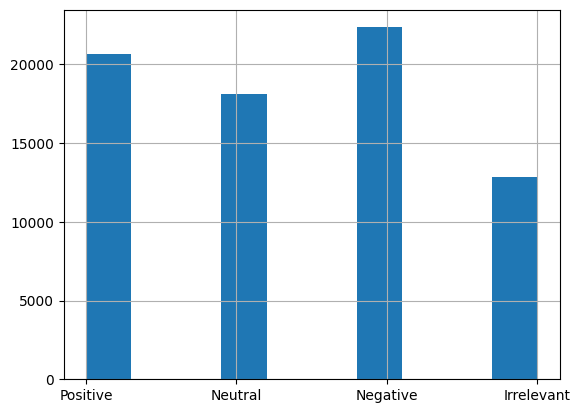

In [ ]:
# Quedémonos solo con las columnas de interés
df = df[['sentiment','Tweet content']]

# Miremos cuáles clases hay en este dataset y cuántos elementos por cada una de ellas
df['sentiment'].hist()

In [ ]:
# filter positive and negative sentiments only
df = df[(df.sentiment == 'Positive') | (df.sentiment == 'Negative')]

# Las mapeamos para que queden en 0 y 1
target_map = { 'Positive': 1, 'Negative': 0}
df['target'] = df['sentiment'].map(target_map)

texts = df['Tweet content'].to_list()

<ipython-input-13-eaa2360b2724>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['target'] = df['sentiment'].map(target_map)


In [ ]:
### Cuando usemos modelos de huggingface debemos verificar qué pipeline traen
### integrado y el nombre exacto del modelo

# Por ejemplo, en este modelo
# model="cardiffnlp/twitter-roberta-base-sentiment-latest"
# el pipeline es de text-classification

# mientras que en este
# model="distilbert/distilbert-base-uncased-finetuned-sst-2-english"
# el pipeline es de sentiment-analysis

# en este modelo
# model="nlptown/bert-base-multilingual-uncased-sentiment"
# el pipeline también es de text-classification


## --------------- Seleccionamos solo uno de los siguientes -------------------

"""
classification = pipeline(
    "sentiment-analysis",
    model="distilbert/distilbert-base-uncased-finetuned-sst-2-english",
    revision="714eb0f"  # Opcional: podemos especificar la versión específica
)

classification = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest"
)


classification = pipeline(
    "text-classification", model="nlptown/bert-base-multilingual-uncased-sentiment"
)
"""

classification = pipeline(
    "text-classification", model="cardiffnlp/twitter-roberta-base-sentiment"
)

texts_N = texts[:20]

predictions = classification(texts_N)

df_results = pd.DataFrame({'Prediction': predictions,'Tweet': texts_N})
print(df_results.to_string(index=False))  # Print without index

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

                                       Prediction                                                                                                                                                                                                                                                                                                 Tweet
{'label': 'LABEL_0', 'score': 0.8432263731956482}                                                                                                                                                                                                                                                   I am coming to the borders and I will kill you all,
{'label': 'LABEL_0', 'score': 0.8462831974029541}                                                                                                                                                                                                                                                    im getting on borde

---
## **Sección 8: FRASES DE EJEMPLO** - **Las siguientes frases pueden usarse para ejecutar las pruebas en las siguientes celdas de código**
---

### Positive:
"I'm absolutely thrilled with my new laptop; it's faster than I ever imagined!"

### Negative:
"The service at the restaurant was terrible, and the food tasted bland."

### Mixed:
"I love the sleek design of this phone, but the battery life is awful."

### Neutral/Somewhat Mixed:
"It was an average movie—entertaining enough, but nothing special."

### Highly Positive:
"Everything about this hotel was perfect; I’m definitely coming back!"

### Frustration:
"I can’t stand waiting in this endless queue; it’s driving me insane!"

### Slightly Negative:
"The speaker’s presentation had potential, but it was too long and repetitive."

### Very Positive:
"The tutorial you provided was incredibly helpful, and I learned so much!"

### Regretful:
"I regret buying that gadget; it stopped working after just two days."

### Overall Neutral:
"The product arrived on time, and it matches the description, so I have no complaints."